# Milestone 2 — Reproducing the Baseline of Datta *et al.* (2021) on HAM10000

**Base paper:** S. K. Datta, S. M. A. Hashemi, S. N. Srihari, M. Gao, *"Soft-Attention Improves Skin Cancer Classification Performance,"* iMIMIC @ MICCAI 2021, LNCS 12929. [arXiv:2105.03358](https://arxiv.org/abs/2105.03358) · [official code](https://github.com/skrantidatta/Attention-based-Skin-Cancer-Classification)

**Team:** Navnit Naman (230085), Kanhaiya Kumar (230062) — Newton School of Technology, Rishihood University

**Goal:** re-run the paper's method on HAM10000 with the **same protocol**, using the same split logic, preprocessing, backbone and hyper-parameters. Then report precision, recall, AUC and a per-class table, and compare them with the published numbers.

| Run | `MODEL` | Paper target (W.Avg precision / W.Avg AUC) |
|---|---|---|
| **Baseline**: Inception-ResNet-v2 | `"irv2"` | **0.905 / 0.982** |
| Proposed: IRv2 + Soft-Attention | `"irv2_sa"` | **0.937 / 0.984** |

### How to run
1. **Kaggle (recommended):** New Notebook → *File → Import Notebook* → upload this file. Add input dataset **`kmader/skin-cancer-mnist-ham10000`**, set Accelerator to **GPU T4 / P100** and Internet **On** (for ImageNet weights). Then use *Save Version → Save & Run All*, which runs in the background for up to 12 h, so you can close the browser.
2. **Colab:** Runtime → GPU. The data cell downloads HAM10000 through `kagglehub`. Colab can disconnect, but the `BackupAndRestore` callback resumes training if you re-run.
3. Run once with `MODEL="irv2"` (baseline, the Milestone 2 deliverable). If GPU time remains, run again with `MODEL="irv2_sa"`.

Expected time is about 2.5–5 h per run on a free T4/P100. The authors' log shows ~146 s/epoch with early stopping near epoch 58.

> *No clinical claims are made. This is a benchmark reproduction on a curated research dataset.*

## 1. Configuration

In [1]:
import os

MODEL     = "irv2_sa"      # "irv2" = baseline (no attention) | "irv2_sa" = with Soft-Attention
PROTOCOL  = "paper"     # "paper" = exact authors' protocol (test set doubles as validation set)
                        # "clean" = lesion-grouped validation split carved from train; test touched once
SEED      = 42          # the authors set no seed; we fix one so the run is repeatable

# --- hyper-parameters exactly as in the official notebooks ---
IMG_SIZE      = 299     # IRv2 input
BATCH_SIZE    = 16
EPOCHS        = 150
PATIENCE      = 30      # EarlyStopping(monitor="val_loss", patience=30, min_delta=0.001)
LR, ADAM_EPS  = 0.01, 0.1
TEST_SIZE     = 0.15    # 85/15 split
AUG_TARGET    = 8000    # offline augmentation target per class
AUG_BATCH     = 50      # generator batch size used by the authors (affects exact image counts)
CLASS_WEIGHTS = {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 5.0, 5: 1.0, 6: 1.0}  # mel x5 (in code, not in paper)

# --- engineering options (do not change the method) ---
MIXED_PRECISION = False  # True ~1.5-2x faster on T4 but is a deviation from the paper; keep False for M2
DATA_DIR        = None   # set manually if auto-detection fails (folder containing HAM10000_metadata.csv)

# QUICK_CHECK=1 runs a tiny smoke test (few images, 1 epoch, no ImageNet download) to verify the pipeline
QUICK_CHECK = os.environ.get("QUICK_CHECK", "0") == "1"
if QUICK_CHECK:
    AUG_TARGET, AUG_BATCH, EPOCHS, PATIENCE = 60, 10, 1, 1

CLASSES  = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]   # alphabetical = Keras flow_from_directory order
RUN_NAME = f"{MODEL}_{PROTOCOL}_seed{SEED}" + ("_quick" if QUICK_CHECK else "")
ON_KAGGLE = os.path.isdir("/kaggle/working")
WORK_DIR = "/kaggle/working" if ON_KAGGLE else os.path.abspath("work")
# Colab tip: mount Drive and set WORK_DIR = "/content/drive/MyDrive/ham_m2" so results survive a disconnect
OUT_DIR  = os.path.join(WORK_DIR, "runs", RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)
print("Run:", RUN_NAME, "| outputs ->", OUT_DIR)

Run: irv2_sa_paper_seed42 | outputs -> /kaggle/working/runs/irv2_sa_paper_seed42


## 2. Environment

In [2]:
import json, math, glob, time, random, shutil, platform
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score)
from concurrent.futures import ThreadPoolExecutor

keras.utils.set_random_seed(SEED)          # seeds python, numpy and TF
gpus = tf.config.list_physical_devices("GPU")
print("Python", platform.python_version(), "| TF", tf.__version__, "| Keras", keras.__version__)
print("GPUs:", gpus or "NONE (training on CPU is not feasible for the full run)")
if MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
# Kaggle "GPU T4 x2": mirror the model on both GPUs. The global batch stays 16 (8 per GPU) to match the paper.
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print("replicas in sync:", strategy.num_replicas_in_sync)

Python 3.13.15 | TF 2.20.0 | Keras 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
replicas in sync: 2


I0000 00:00:1791062975.077039      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791062975.080775      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Data: locate and verify HAM10000

In [3]:
def find_data_dir():
    if DATA_DIR:
        return DATA_DIR
    for root in ["/kaggle/input", "/content", os.getcwd()]:
        hits = glob.glob(os.path.join(root, "**", "HAM10000_metadata.csv"), recursive=True)
        if hits:
            return os.path.dirname(hits[0])
    import kagglehub                       # Colab / local fallback (public dataset)
    return kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

data_dir = find_data_dir()
meta = pd.read_csv(os.path.join(data_dir, "HAM10000_metadata.csv"))

# image paths (the Kaggle mirror ships part_1 / part_2, sometimes twice in different case -> de-duplicate by id)
img_path = {}
for p in glob.glob(os.path.join(data_dir, "**", "*.jpg"), recursive=True):
    img_path.setdefault(os.path.splitext(os.path.basename(p))[0], p)
meta = meta[meta["image_id"].isin(img_path)].reset_index(drop=True)
meta["path"] = meta["image_id"].map(img_path)

if QUICK_CHECK:  # tiny stratified subset that keeps multi-image lesions
    meta = meta.groupby("dx").head(30).reset_index(drop=True)

print("data dir:", data_dir)
print(f"images: {len(meta):,} | distinct lesions: {meta.lesion_id.nunique():,}")
dist = meta["dx"].value_counts().reindex(CLASSES).to_frame("images")
dist["%"] = (100 * dist["images"] / dist["images"].sum()).round(1)
dist

data dir: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
images: 10,015 | distinct lesions: 7,470


,images,%
dx,,
akiec,327,3.3
bcc,514,5.1
bkl,1099,11.0
df,115,1.1
mel,1113,11.1
nv,6705,66.9
vasc,142,1.4


In [4]:
if not QUICK_CHECK:
    assert len(meta) == 10015, "expected 10,015 images"
    assert meta.lesion_id.nunique() == 7470, "expected 7,470 lesions"
    print("Dataset matches the HAM10000 descriptor (10,015 images / 7,470 lesions).")

Dataset matches the HAM10000 descriptor (10,015 images / 7,470 lesions).


## 4. Train/test split (the authors' exact logic)

The official notebook does this:
1. Count images per `lesion_id`, and keep lesions that have **exactly one** image as test candidates.
2. Take a stratified 15 % of those candidates as the **test set**. In the paper this gives 828 images.
3. Use **every other image** (9,187) as training data, including all multi-image lesions.

Because the test set uses only single-image lesions, no lesion appears in both train and test. The authors used no `random_state`; we pass `SEED`.

With `PROTOCOL="clean"`, we also hold out a lesion-grouped 10 % of the training images as a separate validation set. This set is used for checkpointing and early stopping, so the test set is used only once at the end.

In [5]:
n_img = meta.groupby("lesion_id")["image_id"].transform("count")
single = meta[n_img == 1]                                         # test candidate pool
_, test_df = train_test_split(single, test_size=TEST_SIZE, stratify=single["dx"], random_state=SEED)
train_df = meta[~meta["image_id"].isin(test_df["image_id"])]

if PROTOCOL == "clean":
    gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
    tr_idx, va_idx = next(gss.split(train_df, groups=train_df["lesion_id"]))
    val_df, train_df = train_df.iloc[va_idx], train_df.iloc[tr_idx]
    assert not set(val_df.lesion_id) & set(train_df.lesion_id)
else:
    val_df = test_df                                              # authors' protocol

assert not set(test_df.lesion_id) & set(train_df.lesion_id), "lesion leakage!"
print(f"train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}   (paper: train 9,187 | test 828)")

paper_support = {"akiec": 23, "bcc": 26, "bkl": 66, "df": 6, "mel": 34, "nv": 663, "vasc": 10}
split_tbl = pd.DataFrame({
    "train (before aug)": train_df.dx.value_counts().reindex(CLASSES),
    "test (ours)": test_df.dx.value_counts().reindex(CLASSES),
    "test (paper)": pd.Series(paper_support),
})
split_tbl

train 9,187 | val 828 | test 828   (paper: train 9,187 | test 828)


,train (before aug),test (ours),test (paper)
akiec,304,23,23
bcc,488,26,26
bkl,1033,66,66
df,109,6,6
mel,1079,34,34
nv,6042,663,663
vasc,132,10,10


## 5. Offline augmentation (after the split)

The authors used Keras `ImageDataGenerator` (rotation 180°, width/height shift 0.1, zoom 0.1, horizontal and vertical flips, `fill_mode="nearest"`) to write extra copies of every training class to disk, up to about 8,000 images per class. Images are resized to 299×299 (nearest neighbour) before augmentation.

`ImageDataGenerator` was removed in Keras 3, so we re-implement the same random affine transform with OpenCV. We also copy the generator's batch arithmetic (`ceil((8000-n)/50)` batches of 50, with a short last batch each pass). That reproduces the authors' **51,699** training images exactly.

In [6]:
def n_augmented(n, target=AUG_TARGET, bs=AUG_BATCH):
    # images produced by the authors' loop: num_batches batches cycling over n files in chunks of bs
    num_batches = max(0, math.ceil((target - n) / bs))
    pattern = [bs] * (n // bs) + ([n % bs] if n % bs else [])
    return sum(pattern[i % len(pattern)] for i in range(num_batches))

def random_affine(img, rng):
    # ImageDataGenerator(rotation_range=180, width/height_shift_range=0.1, zoom_range=0.1,
    #                    horizontal_flip=True, vertical_flip=True, fill_mode='nearest')
    h, w = img.shape[:2]
    theta = np.deg2rad(rng.uniform(-180, 180))
    tx, ty = rng.uniform(-0.1, 0.1) * h, rng.uniform(-0.1, 0.1) * w
    zx, zy = rng.uniform(0.9, 1.1, size=2)
    R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
    Z = np.array([[zx, 0, 0], [0, zy, 0], [0, 0, 1]])
    M = R @ T @ Z
    o = np.array([[1, 0, h / 2 - 0.5], [0, 1, w / 2 - 0.5], [0, 0, 1]])          # transform about centre
    M = o @ M @ np.linalg.inv(o)
    # Keras matrices act on (row, col); convert to OpenCV's (x=col, y=row) convention
    P = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]])
    M_cv = P @ M @ P
    out = cv2.warpAffine(img, M_cv[:2], (w, h), flags=cv2.INTER_NEAREST | cv2.WARP_INVERSE_MAP,
                         borderMode=cv2.BORDER_REPLICATE)
    if rng.random() < 0.5: out = out[:, ::-1]
    if rng.random() < 0.5: out = out[::-1, :]
    return out

def load_resized(path):
    img = cv2.imread(path)                                         # BGR, kept as BGR for writing
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

# on Kaggle keep the ~1.3 GB augmented set in /tmp so it is not saved as notebook output
AUG_DIR = os.path.join("/tmp" if ON_KAGGLE else WORK_DIR, "aug", f"{PROTOCOL}_seed{SEED}" + ("_quick" if QUICK_CHECK else ""))
manifest_path = os.path.join(AUG_DIR, "manifest.csv")

if os.path.exists(manifest_path):
    aug_df = pd.read_csv(manifest_path)
    print("re-using augmented set:", AUG_DIR)
else:
    t0, rows = time.time(), []
    for ci, c in enumerate(CLASSES):
        os.makedirs(os.path.join(AUG_DIR, c), exist_ok=True)
        src = train_df.loc[train_df.dx == c, "path"].tolist()
        k = n_augmented(len(src))
        order = []                                                  # cycle through the class like the generator
        rng_c = np.random.default_rng(SEED + ci)
        while len(order) < k:
            order += list(rng_c.permutation(len(src)))
        order = order[:k]

        def make(j, c=c, src=src, ci=ci, order=order):
            rng = np.random.default_rng([SEED, ci, j])
            out = random_affine(load_resized(src[order[j]]), rng)
            dst = os.path.join(AUG_DIR, c, f"aug_{j:05d}.jpg")
            cv2.imwrite(dst, out)
            return dst
        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            dsts = list(ex.map(make, range(k)))
        rows += [(p, c) for p in src] + [(p, c) for p in dsts]
        print(f"{c:>6}: {len(src):5d} originals + {k:5d} augmented = {len(src) + k:5d}")
    aug_df = pd.DataFrame(rows, columns=["path", "dx"])
    aug_df.to_csv(manifest_path, index=False)
    print(f"augmentation took {time.time() - t0:.0f}s")

print(f"training images after augmentation: {len(aug_df):,}   (authors' notebook: 51,699)")

 akiec:   304 originals +  6688 augmented =  6992
   bcc:   488 originals +  7370 augmented =  7858
   bkl:  1033 originals +  6898 augmented =  7931
    df:   109 originals +  5768 augmented =  5877
   mel:  1079 originals +  6824 augmented =  7903
    nv:  6042 originals +  2000 augmented =  8042
  vasc:   132 originals +  6964 augmented =  7096
augmentation took 184s
training images after augmentation: 51,699   (authors' notebook: 51,699)


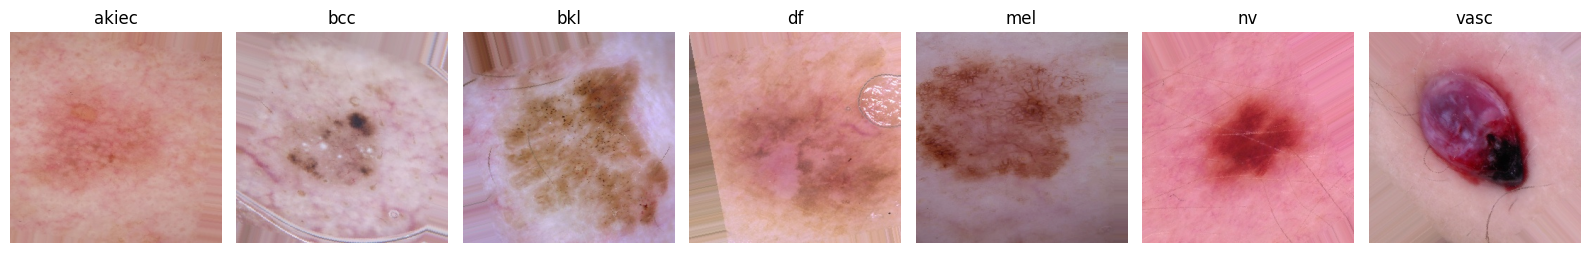

In [7]:
# sanity check: a few augmented samples
fig, axs = plt.subplots(1, 7, figsize=(16, 2.6))
for ax, c in zip(axs, CLASSES):
    p = aug_df[(aug_df.dx == c) & aug_df.path.str.contains("aug_")].path.iloc[0]
    ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); ax.set_title(c); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Input pipeline

The authors used `flow_from_directory(target_size=(299,299))`, which resizes with nearest neighbour, followed by `inception_resnet_v2.preprocess_input` (scales pixels to [-1, 1]). We do the same with `tf.data`, which reads images in parallel and is much faster on a free GPU. There is no online augmentation during training, as in the original code.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
preprocess = keras.applications.inception_resnet_v2.preprocess_input
cls_index = {c: i for i, c in enumerate(CLASSES)}

def decode(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="nearest")
    img = preprocess(tf.cast(img, tf.float32))
    return img, tf.one_hot(label, len(CLASSES))

def make_ds(df, train):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["dx"].map(cls_index).values))
    if train:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.map(decode, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

# keep test order sorted by class (like flow_from_directory) so outputs are easy to read
test_df = test_df.assign(_c=test_df.dx.map(cls_index)).sort_values(["_c", "image_id"]).drop(columns="_c")
val_df = test_df if PROTOCOL == "paper" else val_df
train_ds, val_ds, test_ds = make_ds(aug_df, True), make_ds(val_df, False), make_ds(test_df, False)
STEPS_PER_EPOCH = math.ceil(len(train_df) / 10)  # authors: steps_per_epoch = len(train_df)/10  -> 919
print("steps/epoch:", STEPS_PER_EPOCH, "| images seen per epoch:", STEPS_PER_EPOCH * BATCH_SIZE)

steps/epoch: 919 | images seen per epoch: 14704


## 7. Model

**Backbone.** ImageNet Inception-ResNet-v2, cut where the authors cut it (`irv2.layers[-28]` in TF 2.4). That layer is the BatchNorm of the first 1×1 conv (192 ch, 8×8) in branch 1 of block `block8_9`. Keras 3 orders layers differently, so we locate it **by graph position** and check the parameter count against the authors' `model.summary()`. All layers are trainable.

**Baseline head:** ReLU → Dropout(0.5) → Flatten → Dense(7, softmax).

**Soft-Attention head:** SoftAttention(16 heads), giving an attention-weighted map. Both that map and the original features go through MaxPool 2×2, then Concat → ReLU → Dropout(0.5) → Flatten → Dense(7).

The `SoftAttention` layer is ported line-for-line from the official code to Keras 3 / `tf` ops. Two details of the code differ from the paper text, and we keep the code's behaviour:
- The 3-D convolution kernel has shape `(C, 3, 3)` over the `(H, W, C)` axes, with stride C along channels.
- There is **no learnable scalar γ**, even though Eq. 1 of the paper includes one.

In [9]:
@keras.saving.register_keras_serializable()
class SoftAttention(layers.Layer):
    # Port of the authors' SoftAttention (aggregate / concat options kept)
    def __init__(self, ch, m, concat_with_x=False, aggregate=False, **kwargs):
        super().__init__(**kwargs)
        self.channels, self.multiheads = int(ch), m
        self.aggregate_channels, self.concat_input_with_scaled = aggregate, concat_with_x

    def build(self, input_shape):
        self.i_shape = tuple(input_shape)
        self.kernel_conv3d = self.add_weight(shape=(self.channels, 3, 3, 1, self.multiheads),
                                             initializer="he_uniform", name="kernel_conv3d")
        self.bias_conv3d = self.add_weight(shape=(self.multiheads,), initializer="zeros", name="bias_conv3d")

    def call(self, x):
        h, w, c = self.i_shape[1], self.i_shape[2], self.i_shape[3]
        exp_x = tf.expand_dims(x, -1)                                           # (B,H,W,C,1)
        k = tf.cast(self.kernel_conv3d, x.dtype)
        c3d = tf.nn.conv3d(exp_x, k, strides=[1, 1, 1, c, 1], padding="SAME")  # (B,H,W,1,m)
        c3d = tf.nn.relu(tf.nn.bias_add(c3d, tf.cast(self.bias_conv3d, x.dtype)))
        c3d = tf.squeeze(tf.transpose(c3d, (0, 4, 1, 2, 3)), -1)               # (B,m,H,W)
        alpha = tf.nn.softmax(tf.reshape(c3d, (-1, self.multiheads, h * w)), axis=-1)
        alpha = tf.reshape(alpha, (-1, self.multiheads, h, w))
        if not self.aggregate_channels:
            a = tf.transpose(tf.expand_dims(alpha, -1), (0, 2, 3, 1, 4))         # (B,H,W,m,1)
            u = a * tf.expand_dims(x, -2)                                       # (B,H,W,m,C)
            u = tf.reshape(u, (-1, h, w, self.multiheads * c))
        else:
            a = tf.reduce_sum(tf.transpose(alpha, (0, 2, 3, 1)), -1, keepdims=True)  # (B,H,W,1)
            u = a * x
        o = tf.concat([u, x], -1) if self.concat_input_with_scaled else u
        return [o, alpha]

    def compute_output_shape(self, input_shape):
        h, w, c = input_shape[1:]
        if not self.aggregate_channels:
            out_c = c + c * self.multiheads
        else:
            out_c = 2 * c if self.concat_input_with_scaled else c
        return [(input_shape[0], h, w, out_c), (input_shape[0], self.multiheads, h, w)]

    def get_config(self):
        return {**super().get_config(), "ch": self.channels, "m": self.multiheads,
                "concat_with_x": self.concat_input_with_scaled, "aggregate": self.aggregate_channels}


def build_model(kind):
    irv2 = keras.applications.InceptionResNetV2(include_top=True, classifier_activation="softmax",
                                                weights=None if QUICK_CHECK else "imagenet")
    names = [l.name for l in irv2.layers]
    # authors' cut point: BN after the first 1x1 conv (192 ch) that consumes block8_8_ac
    cut = irv2.layers[names.index("block8_8_ac") + 2]
    assert isinstance(cut, layers.BatchNormalization) and tuple(cut.output.shape[1:]) == (8, 8, 192), cut.name
    build_model.cut_name = cut.name
    conv = cut.output
    if kind == "irv2_sa":
        att, _ = SoftAttention(aggregate=True, m=16, concat_with_x=False, ch=int(conv.shape[-1]),
                               name="soft_attention")(conv)
        att = layers.MaxPooling2D(pool_size=(2, 2), padding="same")(att)
        conv = layers.MaxPooling2D(pool_size=(2, 2), padding="same")(conv)
        conv = layers.concatenate([conv, att])
    conv = layers.Activation("relu")(conv)
    conv = layers.Dropout(0.5)(conv)
    out = layers.Flatten()(conv)
    out = layers.Dense(len(CLASSES), activation="softmax", dtype="float32")(out)
    return keras.Model(irv2.input, out, name=kind)

with strategy.scope():
    model = build_model(MODEL)
expected = {"irv2": 47_550_631, "irv2_sa": 47_535_287}[MODEL]            # from the authors' model.summary()
print(f"cut layer: {build_model.cut_name} | params: {model.count_params():,} "
      f"(authors: {expected:,}) -> {'MATCH' if model.count_params() == expected else 'MISMATCH'}")

225209952/225209952 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
cut layer: batch_normalization_196 | params: 47,535,287 (authors: 47,535,287) -> MATCH


## 8. Training (authors' settings)

- Adam (lr = 0.01, ε = 0.1), categorical cross-entropy, class weight ×5 on `mel`
- 150 epochs maximum, `steps_per_epoch = len(train_df)/10`, batch size 16
- `ModelCheckpoint(monitor="val_accuracy", save_best_only=True)` and `EarlyStopping(monitor="val_loss", patience=30, min_delta=0.001)`

> ⚠️ Under `PROTOCOL="paper"` the validation set **is the test set**, exactly as in the official code. Both the checkpoint choice and early stopping therefore see test labels, so the reported numbers are optimistic. We reproduce this faithfully for comparison and discuss it in Section 11.

In [10]:
with strategy.scope():
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR, epsilon=ADAM_EPS),
                  loss="categorical_crossentropy", metrics=["accuracy"])

class EpochTimer(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None): self.t = time.time()
    def on_epoch_end(self, epoch, logs=None): logs["epoch_time_s"] = time.time() - self.t

ckpt_path = os.path.join(OUT_DIR, "best.weights.h5")
callbacks = [
    EpochTimer(),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, save_weights_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE, min_delta=0.001),
    keras.callbacks.BackupAndRestore(os.path.join(OUT_DIR, "backup")),    # resume after a Colab disconnect
    keras.callbacks.CSVLogger(os.path.join(OUT_DIR, "history.csv"), append=True),
]

t0 = time.time()
history = model.fit(train_ds, steps_per_epoch=STEPS_PER_EPOCH, epochs=EPOCHS, validation_data=val_ds,
                    class_weight=CLASS_WEIGHTS, callbacks=callbacks, verbose=2)
train_time_h = (time.time() - t0) / 3600
print(f"training wall-clock: {train_time_h:.2f} h on {gpus[0].name if gpus else 'CPU'}")

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1791063313.999175      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/irv2_sa_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
919/919 - 585s - 636ms/step - accuracy: 0.4423 - loss: 2.1970 - val_accuracy: 0.7681 - val_loss: 0.5916 - epoch_time_s: 579.3485
Epoch 2/150
919/919 - 467s - 508ms/step - accuracy: 0.6155 - loss: 1.3002 - val_accuracy: 0.6860 - val_loss: 0.9931 - epoch_time_s: 463.5650
Epoch 3/150
919/919 - 466s - 507ms/step - accuracy: 0.6638 - loss: 1.1622 - val_accuracy: 0.6630 - val_loss: 0.8867 - epoch_time_s: 462.8628
Epoch 4/150
919/919 - 469s - 510ms/step - accuracy: 0.7344 - loss: 0.9298 - val_accuracy: 0.8478 - val_loss: 0.4092 - epoch_time_s: 462.9306
Epoch 5/150
919/919 - 466s - 507ms/step - accuracy: 0.7588 - loss: 0.8534 - val_accuracy: 0.7826 - val_loss: 0.6428 - epoch_time_s: 463.3886
Epoch 6/150
919/919 - 470s - 512ms/step - accuracy: 0.7796 - loss: 0.7692 - val_accuracy: 0.8780 - val_loss: 0.3750 - epoch_time_s: 464.5734
Epoch 7/150
919/919 - 469s

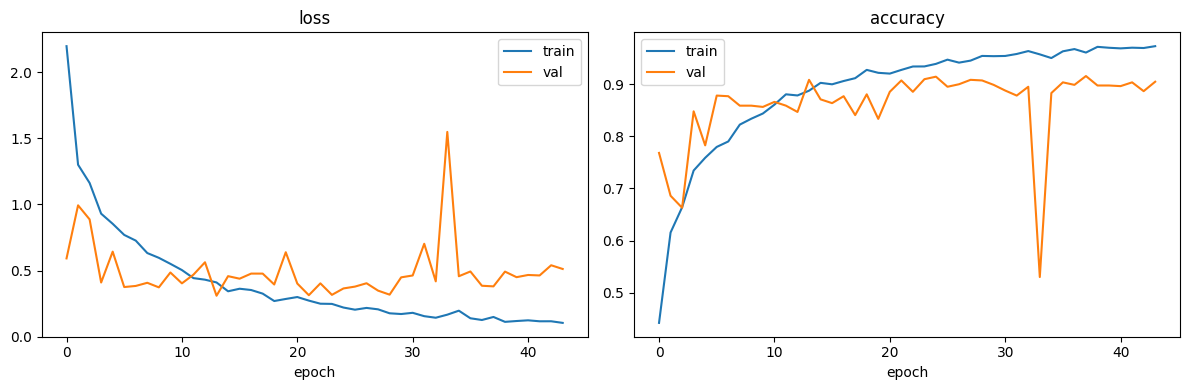

epochs run: 44 | best val_accuracy at epoch 38 | mean epoch time: 467s


In [11]:
hist = pd.read_csv(os.path.join(OUT_DIR, "history.csv"))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.epoch, hist.loss, label="train"); ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist.epoch, hist.accuracy, label="train"); ax[1].plot(hist.epoch, hist.val_accuracy, label="val")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "curves.png"), dpi=120); plt.show()
best_ep = int(hist.val_accuracy.idxmax())
print(f"epochs run: {len(hist)} | best val_accuracy at epoch {best_ep + 1} | "
      f"mean epoch time: {hist.epoch_time_s.mean():.0f}s")

## 9. Evaluation on the held-out test set

In [12]:
model.load_weights(ckpt_path)
y_prob = model.predict(test_ds, verbose=0)
y_true = test_df["dx"].map(cls_index).values
y_pred = y_prob.argmax(1)
Y = np.eye(len(CLASSES))[y_true]

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))

def specificity(y_t, y_p, k):
    neg = y_t != k
    return float(((y_p != k) & neg).sum() / neg.sum())

summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "balanced_accuracy (=macro recall)": balanced_accuracy_score(y_true, y_pred),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "auc_weighted_ovr": roc_auc_score(Y, y_prob, average="weighted", multi_class="ovr"),
    "auc_macro_ovr": roc_auc_score(Y, y_prob, average="macro", multi_class="ovr"),
}
per_class = pd.DataFrame({
    "support": np.bincount(y_true, minlength=7),
    "precision": precision_score(y_true, y_pred, average=None, labels=range(7), zero_division=0),
    "recall (sensitivity)": recall_score(y_true, y_pred, average=None, labels=range(7), zero_division=0),
    "specificity": [specificity(y_true, y_pred, k) for k in range(7)],
    "f1": f1_score(y_true, y_pred, average=None, labels=range(7), zero_division=0),
    "auc": [roc_auc_score(Y[:, k], y_prob[:, k]) if 0 < Y[:, k].sum() < len(Y) else np.nan for k in range(7)],
}, index=CLASSES).round(3)
display(pd.Series(summary).round(4).to_frame("ours"))
per_class

              precision    recall  f1-score   support

       akiec      0.706     0.522     0.600        23
         bcc      0.875     0.808     0.840        26
         bkl      0.848     0.591     0.696        66
          df      0.800     0.667     0.727         6
         mel      0.677     0.618     0.646        34
          nv      0.940     0.988     0.963       663
        vasc      1.000     0.800     0.889        10

    accuracy                          0.918       828
   macro avg      0.835     0.713     0.766       828
weighted avg      0.913     0.918     0.912       828



,ours
accuracy,0.9179
balanced_accuracy (=macro recall),0.7132
precision_weighted,0.9128
precision_macro,0.8351
recall_weighted,0.9179
recall_macro,0.7132
f1_macro,0.7660
auc_weighted_ovr,0.9814
auc_macro_ovr,0.9823


,support,precision,recall (sensitivity),specificity,f1,auc
akiec,23,0.706,0.522,0.994,0.600,0.987
bcc,26,0.875,0.808,0.996,0.840,0.992
bkl,66,0.848,0.591,0.991,0.696,0.973
df,6,0.800,0.667,0.999,0.727,0.998
mel,34,0.677,0.618,0.987,0.646,0.969
nv,663,0.940,0.988,0.745,0.963,0.982
vasc,10,1.000,0.800,1.000,0.889,0.975


## 10. Comparison with the paper

Reference values come from **Table 1** of the paper (per-class precision and AUC) and from the **printed outputs of the authors' own notebooks** (recall, accuracy and macro scores, which the paper does not tabulate). The target is to land *near* the paper; an exact match is not expected.

In [13]:
REF = {  # authors' notebook outputs (consistent with paper Table 1 / Table 3)
    "irv2": {
        "precision": [0.83, 0.85, 0.85, 0.67, 0.70, 0.93, 1.00], "recall": [0.65, 0.85, 0.44, 0.33, 0.56, 0.99, 1.00],
        "auc": [0.993, 0.997, 0.971, 0.983, 0.966, 0.984, 1.000],
        "summary": {"accuracy": 0.912, "precision_weighted": 0.906, "precision_macro": 0.833,
                    "recall_macro": 0.689, "auc_weighted_ovr": 0.983, "auc_macro_ovr": 0.985}},
    "irv2_sa": {
        "precision": [1.00, 0.88, 0.72, 1.00, 0.67, 0.97, 1.00], "recall": [0.52, 0.88, 0.83, 0.17, 0.65, 0.98, 1.00],
        "auc": [0.981, 0.999, 0.982, 0.974, 0.974, 0.984, 1.000],
        "summary": {"accuracy": 0.935, "precision_weighted": 0.938, "precision_macro": 0.892,
                    "recall_macro": 0.719, "auc_weighted_ovr": 0.984, "auc_macro_ovr": 0.985}},
}[MODEL]

cmp_summary = pd.DataFrame({"paper": pd.Series(REF["summary"]),
                            "ours": pd.Series(summary).reindex(REF["summary"].keys())})
cmp_summary["gap (ours - paper)"] = cmp_summary["ours"] - cmp_summary["paper"]
display(cmp_summary.round(3))

cmp_class = pd.DataFrame({
    "prec paper": REF["precision"], "prec ours": per_class["precision"].values,
    "recall paper": REF["recall"], "recall ours": per_class["recall (sensitivity)"].values,
    "auc paper": REF["auc"], "auc ours": per_class["auc"].values,
    "support ours": per_class["support"].values,
}, index=CLASSES)
cmp_class.round(3)

,paper,ours,gap (ours - paper)
accuracy,0.935,0.918,-0.017
precision_weighted,0.938,0.913,-0.025
precision_macro,0.892,0.835,-0.057
recall_macro,0.719,0.713,-0.006
auc_weighted_ovr,0.984,0.981,-0.003
auc_macro_ovr,0.985,0.982,-0.003


,prec paper,prec ours,recall paper,recall ours,auc paper,auc ours,support ours
akiec,1.00,0.706,0.52,0.522,0.981,0.987,23
bcc,0.88,0.875,0.88,0.808,0.999,0.992,26
bkl,0.72,0.848,0.83,0.591,0.982,0.973,66
df,1.00,0.800,0.17,0.667,0.974,0.998,6
mel,0.67,0.677,0.65,0.618,0.974,0.969,34
nv,0.97,0.940,0.98,0.988,0.984,0.982,663
vasc,1.00,1.000,1.00,0.800,1.000,0.975,10


In [14]:
# 95% bootstrap confidence intervals: the test set has only ~6 df / ~10 vasc images
rng = np.random.default_rng(SEED)
boot = {"precision_weighted": [], "recall_macro": [], "mel_recall": [], "auc_weighted_ovr": []}
for _ in range(1000):
    i = rng.integers(0, len(y_true), len(y_true))
    yt, yp, pr = y_true[i], y_pred[i], y_prob[i]
    boot["precision_weighted"].append(precision_score(yt, yp, average="weighted", zero_division=0))
    boot["recall_macro"].append(recall_score(yt, yp, average="macro", zero_division=0))
    boot["mel_recall"].append(recall_score(yt == 4, yp == 4, zero_division=0))
    if len(np.unique(yt)) == 7:
        boot["auc_weighted_ovr"].append(roc_auc_score(np.eye(7)[yt], pr, average="weighted", multi_class="ovr"))
ci = pd.DataFrame({k: np.percentile(v, [2.5, 50, 97.5]) for k, v in boot.items() if v},
                  index=["2.5%", "median", "97.5%"]).T.round(3)
ci

,2.5%,median,97.5%
precision_weighted,0.891,0.914,0.935
recall_macro,0.627,0.715,0.793
mel_recall,0.441,0.613,0.781
auc_weighted_ovr,0.973,0.982,0.989


## 11. Confusion matrix and ROC curves

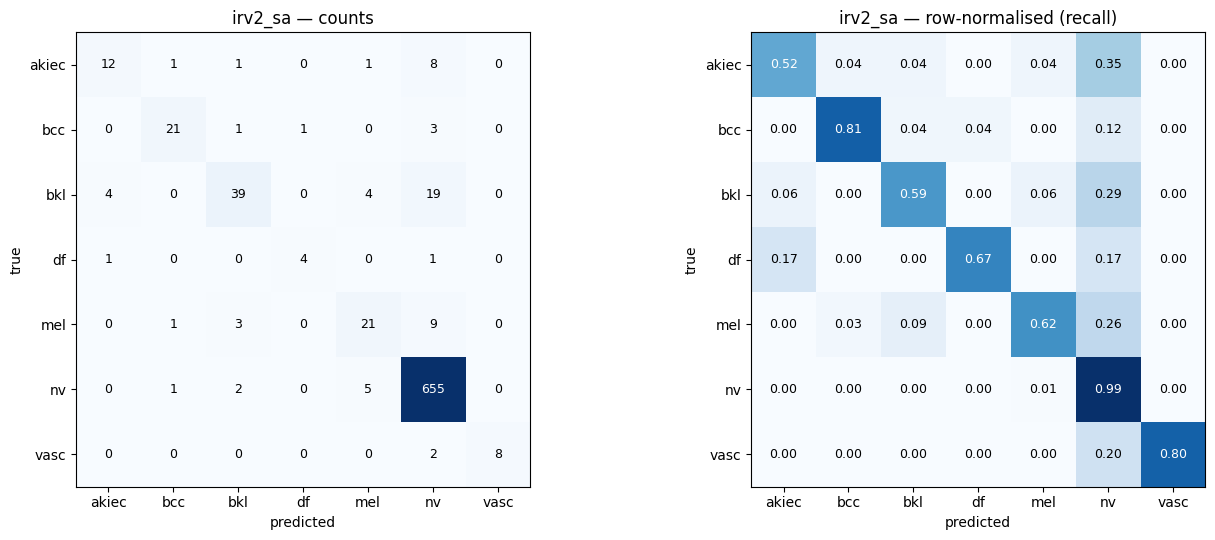

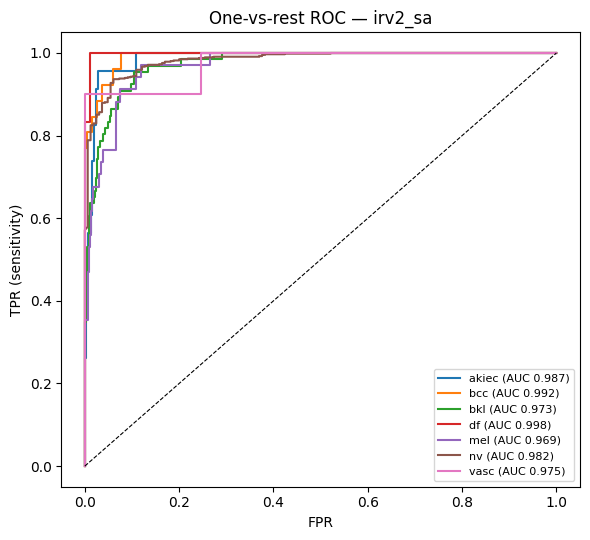

In [15]:
cm = confusion_matrix(y_true, y_pred, labels=range(7))
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, m, t, fmt in [(ax[0], cm, "counts", "d"), (ax[1], cmn, "row-normalised (recall)", ".2f")]:
    im = a.imshow(m, cmap="Blues")
    a.set_xticks(range(7), CLASSES); a.set_yticks(range(7), CLASSES)
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(f"{MODEL} — {t}")
    for r in range(7):
        for c in range(7):
            a.text(c, r, format(m[r, c], fmt), ha="center", va="center",
                   color="white" if m[r, c] > m.max() / 2 else "black", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=120); plt.show()

plt.figure(figsize=(6, 5.5))
for k, c in enumerate(CLASSES):
    if 0 < Y[:, k].sum() < len(Y):
        fpr, tpr, _ = roc_curve(Y[:, k], y_prob[:, k])
        plt.plot(fpr, tpr, label=f"{c} (AUC {per_class.loc[c, 'auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=0.8); plt.xlabel("FPR"); plt.ylabel("TPR (sensitivity)")
plt.title(f"One-vs-rest ROC — {MODEL}"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "roc.png"), dpi=120); plt.show()

In [16]:
# Most frequent confusions (input for the Stage-6 failure analysis)
off = [(CLASSES[r], CLASSES[c], int(cm[r, c])) for r in range(7) for c in range(7) if r != c and cm[r, c]]
pd.DataFrame(sorted(off, key=lambda x: -x[2])[:10], columns=["true", "predicted", "count"])

,true,predicted,count
0,bkl,nv,19
1,mel,nv,9
2,akiec,nv,8
3,nv,mel,5
4,bkl,akiec,4
5,bkl,mel,4
6,bcc,nv,3
7,mel,bkl,3
8,nv,bkl,2
9,vasc,nv,2


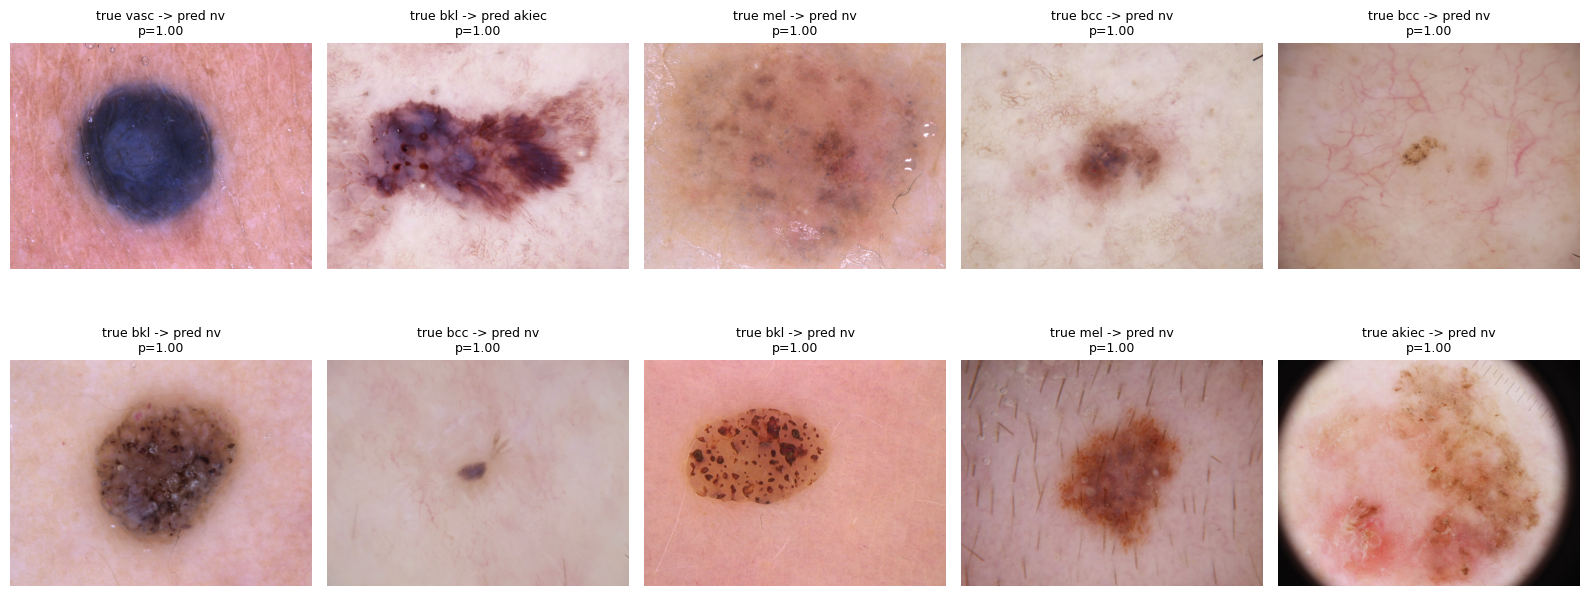

In [17]:
# A few misclassified test images, most confident mistakes first
wrong = np.where(y_pred != y_true)[0]
wrong = wrong[np.argsort(-y_prob[wrong].max(1))][:10]
if len(wrong):
    fig, axs = plt.subplots(2, 5, figsize=(16, 7))
    for a in axs.ravel(): a.axis("off")
    for a, i in zip(axs.ravel(), wrong):
        a.imshow(cv2.cvtColor(cv2.imread(test_df.path.iloc[i]), cv2.COLOR_BGR2RGB))
        a.set_title(f"true {CLASSES[y_true[i]]} -> pred {CLASSES[y_pred[i]]}\np={y_prob[i].max():.2f}", fontsize=9)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "failures.png"), dpi=110); plt.show()

## 12. Save results

In [18]:
pd.DataFrame(y_prob, columns=[f"p_{c}" for c in CLASSES]).assign(
    image_id=test_df.image_id.values, true=test_df.dx.values, pred=[CLASSES[k] for k in y_pred]
).to_csv(os.path.join(OUT_DIR, "test_predictions.csv"), index=False)
per_class.to_csv(os.path.join(OUT_DIR, "per_class.csv"))
cmp_summary.to_csv(os.path.join(OUT_DIR, "comparison_with_paper.csv"))
results = {
    "run": RUN_NAME, "model": MODEL, "protocol": PROTOCOL, "seed": SEED, "quick_check": QUICK_CHECK,
    "tf": tf.__version__, "keras": keras.__version__, "gpu": gpus[0].name if gpus else "CPU",
    "n_train_before_aug": len(train_df), "n_train_after_aug": len(aug_df), "n_val": len(val_df), "n_test": len(test_df),
    "epochs_run": len(hist), "best_epoch": best_ep + 1, "train_time_h": round(train_time_h, 2),
    "params": model.count_params(), "summary": {k: round(float(v), 4) for k, v in summary.items()},
    "per_class": per_class.to_dict(), "bootstrap_ci": ci.to_dict(),
}
with open(os.path.join(OUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)
print("saved to", OUT_DIR); print(sorted(os.listdir(OUT_DIR)))

saved to /kaggle/working/runs/irv2_sa_paper_seed42
['best.weights.h5', 'comparison_with_paper.csv', 'confusion_matrix.png', 'curves.png', 'failures.png', 'history.csv', 'per_class.csv', 'results.json', 'roc.png', 'test_predictions.csv']


## 13. Reproduction notes

### Changes from the official code (porting only; the method is unchanged)
| # | Original (TF 2.4 / Keras 2) | This notebook (TF 2.x / Keras 3) | Why |
|---|---|---|---|
| 1 | `ImageDataGenerator(...).flow_from_directory(save_to_dir=...)` | Same affine transform re-implemented with OpenCV, with the same image counts (51,699) | `ImageDataGenerator` was removed in Keras 3 |
| 2 | `flow_from_directory` loading | `tf.data` with nearest-neighbour resize and the same `preprocess_input` | Speed on a free GPU |
| 3 | `irv2.layers[-28]` | Layer found by graph position; parameter count checked | Keras 3 orders layers differently |
| 4 | `SoftAttention` written with `keras.backend` | Same computation with `tf` ops | `keras.backend` was removed |
| 5 | No seed | `SEED` fixed for the split, augmentation and training | Repeatability |
| 6 | `.hdf5` checkpoint | `.weights.h5`, plus `BackupAndRestore` | Keras 3 API, resume after disconnects |

### Things in the official code that are worth noting (inputs to Milestone 3 / Stage 6)
1. **The test set is the validation set.** It drives checkpoint selection and early stopping (`PROTOCOL="clean"` fixes this).
2. **There is an undocumented class weight** (`mel` × 5) that the paper does not mention.
3. **The SoftAttention code has no learnable γ**, and its 3-D kernel is `(C,3,3)` over `(H,W,C)`, which differs from the paper's description.
4. **Weighted averages are dominated by `nv`** (about 80 % of the test set). Macro recall and per-class recall show the real weakness on the minority classes.
5. **The test set has about 6 `df` and 10 `vasc` images.** One image moves `df` recall by about 17 points, so read the bootstrap CIs above.

### Results (filled in from the Kaggle runs, seed 42, `PROTOCOL="paper"`)
| Model | W.Avg precision | W.Avg AUC | Macro recall | mel recall | Accuracy | Notes |
|---|---|---|---|---|---|---|
| IRv2 (paper) | 0.905 | 0.982 | 0.689* | 0.56* | 0.912* | *from the authors' notebook |
| IRv2 (ours) | 0.909 | 0.978 | 0.720 | 0.441 (15/34) | 0.916 | `cv_project_irv2.ipynb`; 1× T4; 53 epochs (best 52); ~473 s/epoch |
| IRv2 + SA (paper) | 0.937 | 0.984 | 0.719* | 0.65* | 0.934 | |
| IRv2 + SA (ours) | 0.913 | 0.981 | 0.713 | 0.618 (21/34) | 0.918 | `cv_project_irv2_sa.ipynb`; 2× T4 (MirroredStrategy); 44 epochs (best 38); ~467 s/epoch |

**95 % bootstrap intervals (ours):**

| Metric | IRv2 | IRv2 + SA |
|---|---|---|
| W.Avg precision | 0.887 – 0.932 | 0.891 – 0.935 |
| Macro recall | 0.636 – 0.790 | 0.627 – 0.793 |
| mel recall | 0.267 – 0.618 | 0.441 – 0.781 |
| W.Avg AUC | 0.966 – 0.987 | 0.973 – 0.989 |

**Verdict.**
- **IRv2 baseline: reproduced.** Accuracy, weighted precision and weighted AUC are within ±0.012 of the paper.
- **IRv2 + SA: partly reproduced.** AUC matches (−0.003), but weighted precision is 0.025 below the paper.
- **The paper's +3.2-point SA gain is not reproduced.** We measure +0.4 points of weighted precision, and the bootstrap intervals overlap almost completely. SA raised mel recall from 15 to 21 of 34, but with 34 test melanomas the intervals overlap, so one run of each cannot establish it. Run-to-run variance is not yet measured (one run per model); see `reproduction_gap_analysis.md`.